In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [21]:
data = pd.read_csv("academic Stress level - maintainance 1.csv")

print(data.head())
print(data.info())
print(data.isnull().sum())

             Timestamp Your Academic Stage  Peer pressure  \
0  24/07/2025 22:05:39       undergraduate              4   
1  24/07/2025 22:05:52       undergraduate              3   
2  24/07/2025 22:06:39       undergraduate              1   
3  24/07/2025 22:06:45       undergraduate              3   
4  24/07/2025 22:08:06       undergraduate              3   

   Academic pressure from your home Study Environment  \
0                                 5             Noisy   
1                                 4          Peaceful   
2                                 1          Peaceful   
3                                 2          Peaceful   
4                                 3          Peaceful   

          What coping strategy you use as a student?  \
0  Analyze the situation and handle it with intel...   
1  Analyze the situation and handle it with intel...   
2                   Social support (friends, family)   
3  Analyze the situation and handle it with intel...   
4  Analyze

In [22]:
data['Study Environment'] = data['Study Environment'].fillna(data['Study Environment'].mode()[0])
data.drop(columns=['Timestamp'],inplace=True)
# data['Study Environment'].mode()

In [23]:
data.head()
data.isnull().sum()

Your Academic Stage                                                    0
Peer pressure                                                          0
Academic pressure from your home                                       0
Study Environment                                                      0
What coping strategy you use as a student?                             0
Do you have any bad habits like smoking, drinking on a daily basis?    0
What would you rate the academic  competition in your student life     0
Rate your academic stress index                                        0
dtype: int64

In [24]:
encoder=LabelEncoder()
for i in data.columns:
    if(data[i].dtype=="object"):
        data[i]=encoder.fit_transform(data[i])

data.head()


,Your Academic Stage,Peer pressure,Academic pressure from your home,Study Environment,What coping strategy you use as a student?,"Do you have any bad habits like smoking, drinking on a daily basis?",What would you rate the academic competition in your student life,Rate your academic stress index
0,2,4,5,0,0,0,3,5
1,2,3,4,1,0,0,3,3
2,2,1,1,1,2,0,2,4
3,2,3,2,1,0,0,4,3
4,2,3,3,1,0,0,4,5


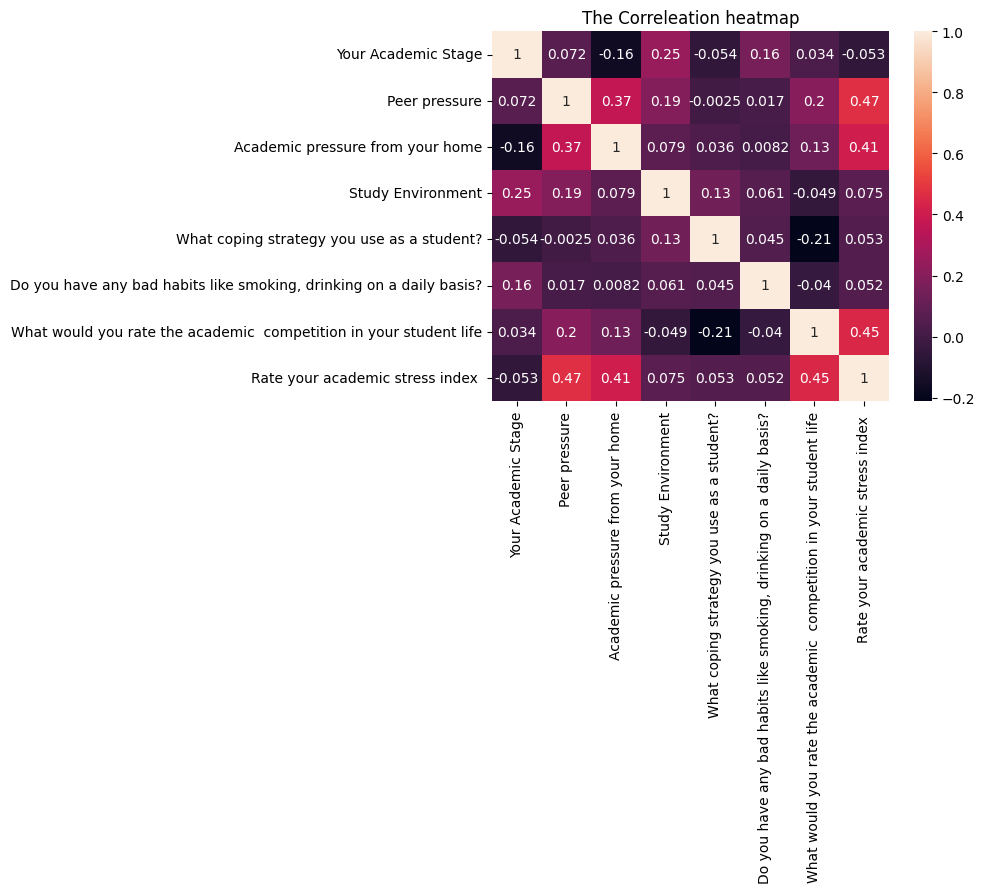

In [25]:
sns.heatmap(data.corr(),annot=True)
plt.title("The Correleation heatmap")
plt.show()

In [26]:

data["ALS"] = (
    data["Peer pressure"] * 0.20 +
    data["Academic pressure from your home"] * 0.20 +
    data["What would you rate the academic  competition in your student life"] * 0.20 +
    data["Rate your academic stress index "] * 0.20+data['Your Academic Stage']*0.20
)

threshold = data["ALS"].mean()

data["Attention_Risk"] = data["ALS"].apply(
    lambda x: 1 if x > threshold else 0
)

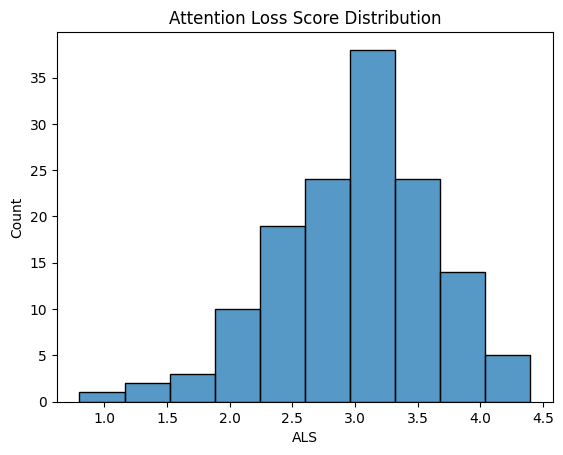

In [27]:
sns.histplot(data["ALS"], bins=10)
plt.title("Attention Loss Score Distribution")
plt.show()

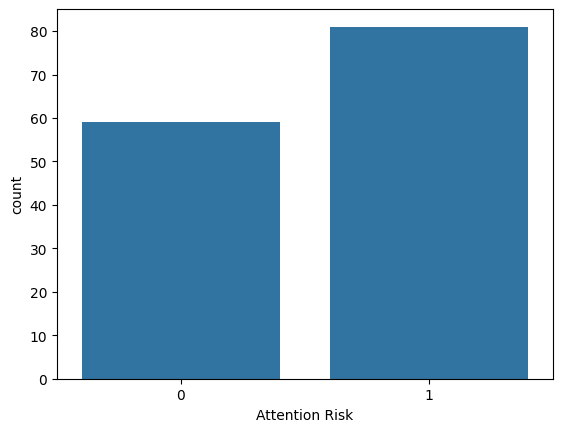

In [28]:
sns.countplot(x='Attention_Risk',data=data)
plt.xlabel("Attention Risk")
plt.show()

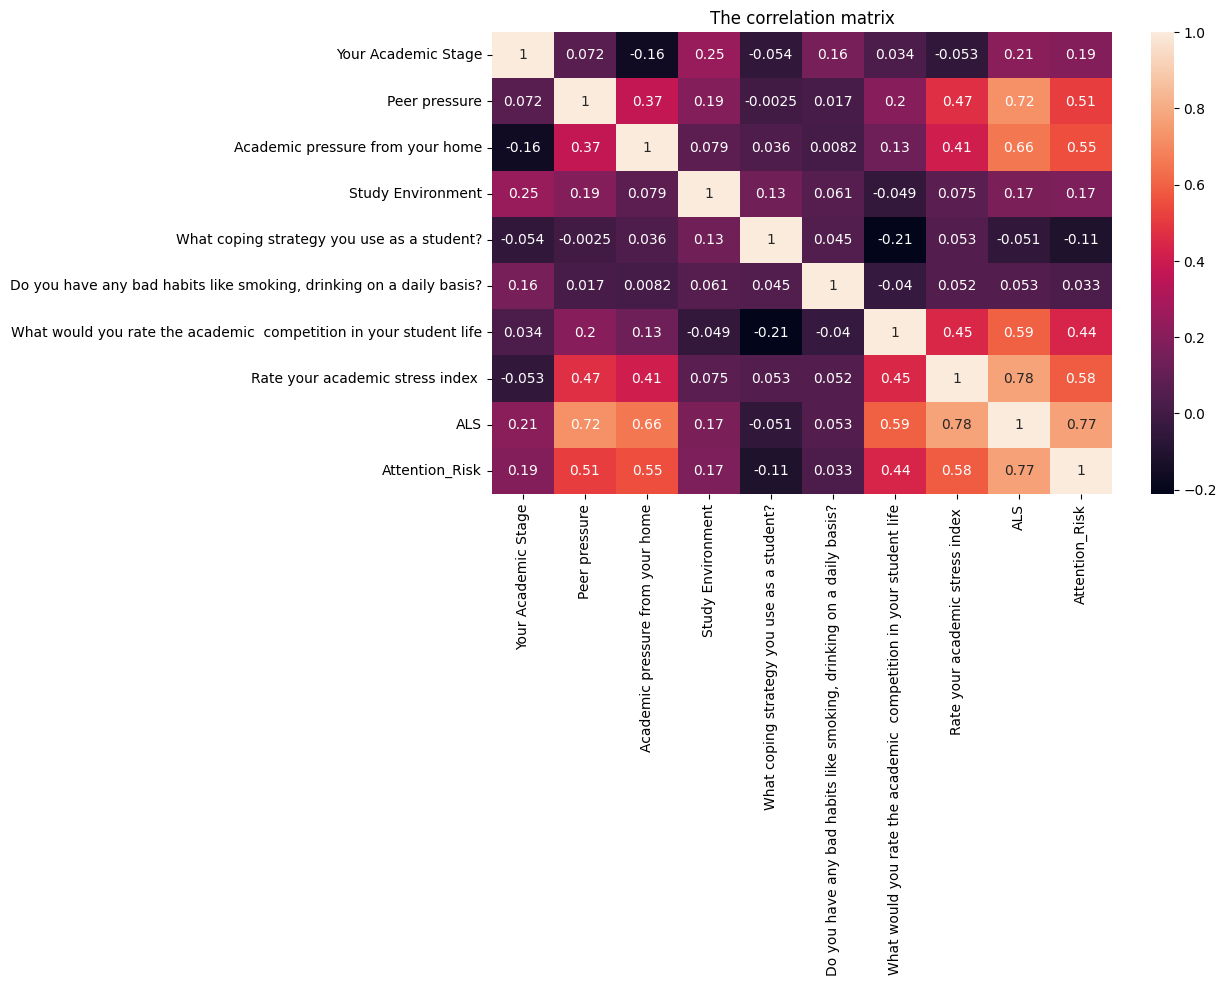

In [29]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(),annot=True)
plt.title("The correlation matrix")
plt.show()

In [34]:
data.columns

Index(['Your Academic Stage', 'Peer pressure',
       'Academic pressure from your home', 'Study Environment',
       'What coping strategy you use as a student?',
       'Do you have any bad habits like smoking, drinking on a daily basis?',
       'What would you rate the academic  competition in your student life',
       'Rate your academic stress index ', 'ALS', 'Attention_Risk'],
      dtype='object')

In [35]:
data.drop(columns=['ALS'])
X = data[
[
"Peer pressure",
"Academic pressure from your home",
"What would you rate the academic  competition in your student life",
"Rate your academic stress index ",
"Your Academic Stage"
]
]
y = data["Attention_Risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [36]:
"Accuracy:", accuracy_score(y_test, y_pred)

classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       1.00      0.91      0.95        11\n           1       0.94      1.00      0.97        17\n\n    accuracy                           0.96        28\n   macro avg       0.97      0.95      0.96        28\nweighted avg       0.97      0.96      0.96        28\n'

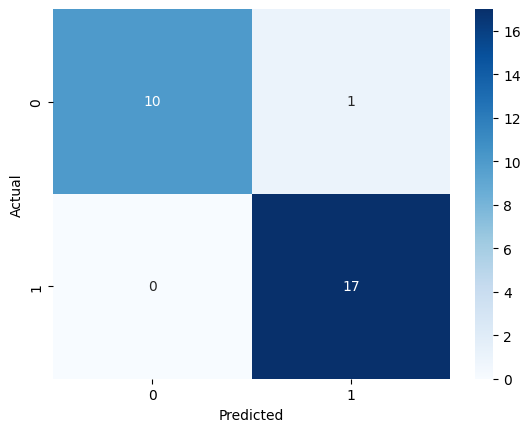

In [37]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [38]:
pickle.dump(model, open("model.pkl", "wb"))

In [39]:
print(model.n_features_in_)

5
